# Bank Customer Churn Analysis

Exploratory analysis of customer churn to identify patterns associated with customers leaving the bank.

## 1. Data Loading

In [1124]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('customer_churn_records_202608221632.csv')

## 2. Initial Data Exploration

In [1125]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,1,3,DIAMOND,456,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425,0


In [1126]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889260,1.530200,0.70550,0.515100,100090.239859,0.204400,3.013800,606.515100,0.203800
std,96.653299,10.487806,2.892174,62397.405166,0.581654,0.45584,0.499797,57510.492795,0.403283,1.405919,225.924839,0.402842
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,119.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,410.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,605.000000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.255000,0.000000,4.000000,801.000000,0.000000
max,850.000000,92.000000,10.000000,250898.100000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,1000.000000,1.000000


In [1127]:
df.groupby('Exited').mean(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned
Exited,,,,,,,,,,,
0,651.837855,37.408063,5.032781,72742.750644,1.544210,0.707109,0.554635,99726.853110,0.001256,3.017960,607.044084
1,645.414622,44.835623,4.934740,91109.475942,1.475466,0.699215,0.360648,101509.908798,0.998037,2.997547,604.448479


## 3. Data Quality Checks

In [1128]:
df.isna().sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
Exited                0
dtype: int64

In [1129]:
df.duplicated().sum()

np.int64(0)

### Finding

The dataset contains no missing values or duplicate rows. All 10,000 customer records are available for analysis.

## 4. Overall Churn Rate

In [1130]:
df['Exited'].mean()


np.float64(0.2038)

## 5. Complaint Analysis

In [1131]:
df.groupby(['Complain', 'Exited']).size()

Complain  Exited
0         0         7952
          1            4
1         0           10
          1         2034
dtype: int64

In [1132]:
df.groupby('Complain')['Exited'].mean()

Complain
0    0.000503
1    0.995108
Name: Exited, dtype: float64

### Finding

Customers who submitted a complaint have an extremely high churn rate: 99.5%, compared with only 0.05% among customers without a complaint.

This relationship is unusually strong and should be interpreted with caution. The dataset does not provide information about when the complaint was submitted relative to customer churn, so no causal conclusion can be made.

## 6. Customer Activity Analysis

In [1133]:
df.groupby(['IsActiveMember', 'Exited']).size()

IsActiveMember  Exited
0               0         3546
                1         1303
1               0         4416
                1          735
dtype: int64

In [1134]:
df.groupby('IsActiveMember')['Exited'].mean()

IsActiveMember
0    0.268715
1    0.142691
Name: Exited, dtype: float64

### Finding

Inactive customers have a substantially higher churn rate than active customers: 26.9% compared with 14.3%.

Customer activity is therefore associated with churn, although the dataset does not establish a causal relationship.

## 7. Age and Customer Activity

In [1135]:
bins = [18, 30, 45, 60, 75, 100]
labels = ['18-29', '30-44', '45-59', '60-74', '75+']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False
)

In [1136]:
age_activity_churn = df.groupby(['AgeGroup', 'IsActiveMember'])['Exited'].mean().unstack()
age_activity_churn.columns = ['Inactive', 'Active']
age_activity_churn

,Inactive,Active
AgeGroup,,
18-29,0.098259,0.053763
30-44,0.181071,0.107191
45-59,0.648709,0.345612
60-74,0.878505,0.142466
75+,0.250000,0.000000


### Finding

Churn increases substantially with age, especially among inactive customers.

For customers aged 45–59, the churn rate is 64.9% among inactive customers compared with 34.6% among active customers. The difference is even larger for customers aged 60–74: 87.9% versus 14.2%.

The 75+ age group should be interpreted with caution because it contains only 54 customers.

## 8. Balance Analysis

In [1137]:
df['Balance'].describe()

count     10000.000000
mean      76485.889260
std       62397.405166
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.100000
Name: Balance, dtype: float64

In [1138]:
balance_zero = df[df['Balance'] == 0]
balance_zero['Exited'].mean()

np.float64(0.13823610727121924)

In [1139]:
balance_positive = df[df['Balance'] > 0].copy()
balance_positive['Exited'].mean()

np.float64(0.2409525301582328)

In [1140]:
balance_positive['BalanceGroup'] = pd.qcut(
    balance_positive['Balance'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [1141]:
balance_positive.groupby('BalanceGroup')['Exited'].mean()

BalanceGroup
Low          0.206767
Medium       0.273810
High         0.253292
Very High    0.229950
Name: Exited, dtype: float64

In [1142]:
balance_positive.groupby('BalanceGroup').size()

BalanceGroup
Low          1596
Medium       1596
High         1595
Very High    1596
dtype: int64

### Finding

Customers with a positive balance have a higher churn rate than customers with a zero balance: 24.1% compared with 13.8%.

However, among customers with a positive balance, churn does not increase consistently as balance grows. The Medium balance group has the highest churn rate at 27.4%, while the Very High group has a lower churn rate of 23.0%.

Therefore, the hypothesis that higher balance is associated with higher churn is not supported by the data.

## 9. Number of Products Analysis

In [1143]:
df['NumOfProducts'].value_counts().sort_index()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [1144]:
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.076035
3    0.827068
4    1.000000
Name: Exited, dtype: float64

### Finding

Customers with two products have the lowest churn rate at 7.6%, compared with 27.7% among customers with one product.

Customers with three and four products show unusually high churn rates: 82.7% and 100% respectively. However, these groups are much smaller, especially the four-product group with only 60 customers.

This pattern should be investigated further before making strong business conclusions.

## 10. Geography Analysis

In [1145]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [1146]:
df.groupby('Geography')['Exited'].mean()

Geography
France     0.161747
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

### Finding

Customers from Germany have a substantially higher churn rate at 32.4%, compared with 16.2% in France and 16.7% in Spain.

Geography is therefore associated with churn in this dataset. However, this does not mean that location itself causes customers to leave, since other customer characteristics may differ between countries.

## 11. Visualizations

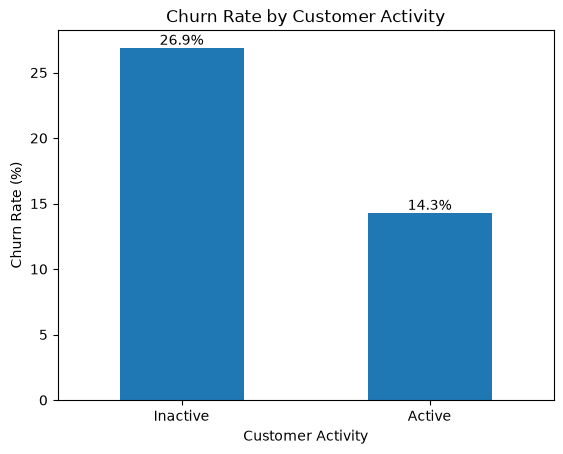

In [1147]:
activity_churn = df.groupby('IsActiveMember')['Exited'].mean()
activity_churn = activity_churn.rename(index={0: 'Inactive', 1: 'Active'})
activity_churn_percent = activity_churn * 100
ax = activity_churn_percent.plot(
    kind='bar',
    title='Churn Rate by Customer Activity',
    xlabel='Customer Activity',
    ylabel='Churn Rate (%)',
    rot=0
)
ax.bar_label(ax.containers[0], fmt='%.1f%%');

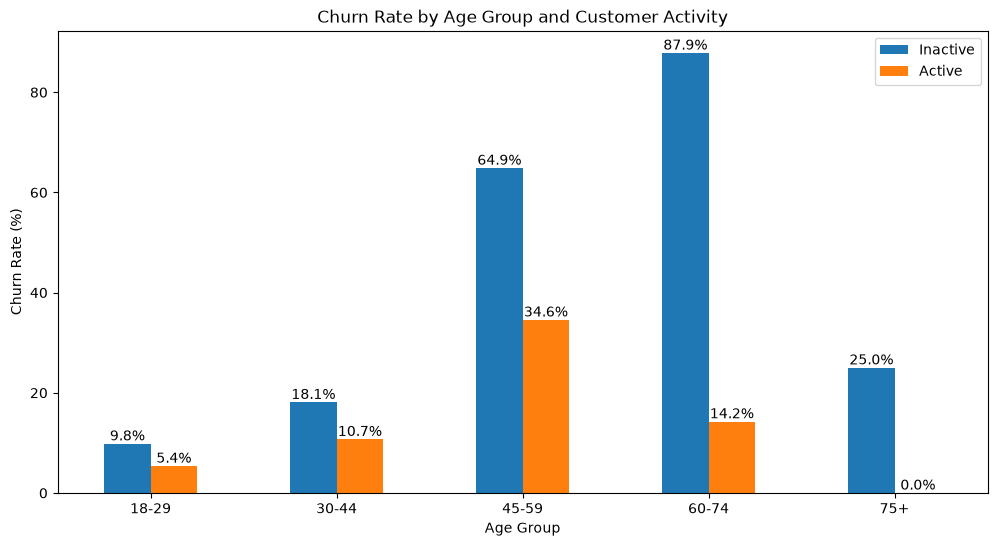

In [ ]:
age_activity_churn_percent = age_activity_churn * 100
ag = age_activity_churn_percent.plot(
    kind='bar',
    title='Churn Rate by Age Group and Customer Activity',
    xlabel='Age Group',
    ylabel='Churn Rate (%)',
    rot=0,
    figsize=(12, 6)
    )
ag.bar_label(ag.containers[0], fmt='%.1f%%', fontsize = 10)
ag.bar_label(ag.containers[1], fmt='%.1f%%', fontsize = 10);

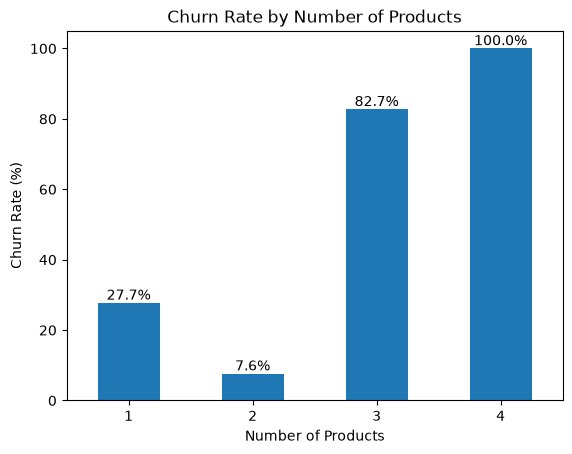

In [ ]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean()
product_churn_percent = product_churn * 100
pc = product_churn_percent.plot(
    kind='bar',
    title='Churn Rate by Number of Products',
    xlabel='Number of Products',
    ylabel='Churn Rate (%)',
    rot=0
)
pc.bar_label(pc.containers[0], fmt='%.1f%%', fontsize=10);

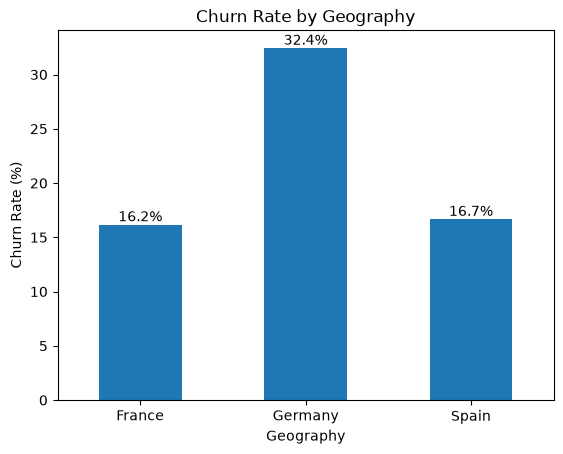

In [ ]:
geography_churn = df.groupby('Geography')['Exited'].mean()
geography_churn_percent = geography_churn * 100
gc = geography_churn_percent.plot(
    kind='bar',
    title='Churn Rate by Geography',
    xlabel='Geography',
    ylabel='Churn Rate (%)',
    rot=0
)
gc.bar_label(gc.containers[0], fmt='%.1f%%', fontsize=10);

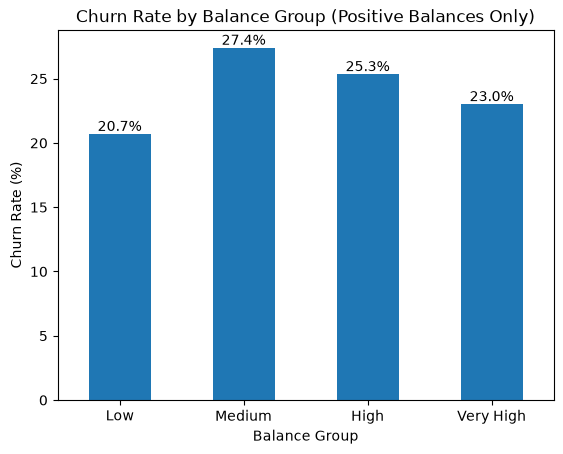

In [1151]:
balance_churn = balance_positive.groupby('BalanceGroup')['Exited'].mean()
balance_churn_percent = balance_churn * 100
bc = balance_churn_percent.plot(
    kind='bar',
    title='Churn Rate by Balance Group (Positive Balances Only)',
    xlabel='Balance Group',
    ylabel='Churn Rate (%)',
    rot=0
)
bc.bar_label(bc.containers[0], fmt='%.1f%%', fontsize=10);

## 12. Key Findings

- **Geography:** Customers from Germany have a churn rate of 32.4%, almost twice the rate observed in France (16.2%) and Spain (16.7%). Further analysis is needed to understand which customer characteristics or market factors may explain this difference.

- **Balance:** Customers with a positive balance have a higher churn rate than customers with a zero balance: 24.1% versus 13.8%. However, among customers with positive balances, churn does not consistently increase as balance grows.

- **Number of Products:** Customers with two products have the lowest churn rate at 7.6%, compared with 27.7% among customers with one product. Customers with three and four products show unusually high churn rates of 82.7% and 100%, although these groups are considerably smaller.

- **Customer Activity and Age:** Inactive customers have a substantially higher churn rate than active customers: 26.9% versus 14.3%. This difference becomes especially large among older customers. For the 60–74 age group, churn reaches 87.9% among inactive customers compared with 14.2% among active customers.

- **Complaints:** Customer complaints are almost perfectly associated with churn. Approximately 99.5% of customers with a complaint exited, compared with only 0.05% of customers without a complaint. Because the dataset does not contain complaint timestamps or additional context, this unusually strong relationship should be interpreted with caution.

## 13. Limitations

- **No event timestamps:** The dataset does not contain information about when complaints or customer exits occurred. Therefore, the temporal relationship between complaints and churn cannot be established, and causal conclusions should not be made.

- **Small sample sizes in some segments:** Some customer groups contain relatively few observations. This is especially important for customers aged 75+ (only 54 customers) and customers with three or four products, so churn rates in these groups should be interpreted with caution.

- **Limited product information:** The dataset provides only the number of products used by each customer, without specifying the product types. This limits the ability to explain why customers with different numbers of products show very different churn rates.

- **Observational analysis:** The analysis identifies associations between customer characteristics and churn, but these relationships do not necessarily represent causal effects.

## 14. Conclusion

This analysis identified several customer characteristics associated with churn, including customer activity, age, number of products, geography, balance status, and complaints.

The strongest patterns were observed among customers with complaints, inactive older customers, customers with three or four products, and customers from Germany. However, these findings should be treated as associations rather than causal relationships.

Further analysis should focus on understanding the reasons behind these patterns, especially the unusually high churn among customers with complaints and multiple products, as well as the higher churn rate observed in Germany. Additional data on event timing, product types, and customer behavior would help provide more reliable explanations and support better retention decisions.